In [76]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [179]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

In [180]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
device

'cuda'

In [187]:
# Create dataset
materiales = pd.read_csv('./structuralparameters-vs-capacities-h2.csv')
materiales

,name,usablegc,usablevc,density,porosity,Ri,ssa,specific
0,cc2s/cc2hg088,4.78,0.0157,0.312,0.84,15.71,4751,2.692
1,cc2s/cc2hj8cp,3.23,0.0145,0.433,0.60,5.70,5445,1.384
2,cc2s/cc2j6dpv,1.64,0.0122,0.728,0.32,4.65,3195,0.440
3,jlu-mof108/dupver_P1,1.63,0.0134,0.813,0.44,4.71,2885,0.541
4,jlu-mof108/heffef_P1_charged,1.82,0.0136,0.733,0.46,4.77,3335,0.627
...,...,...,...,...,...,...,...,...
100,MOF-selected-poro-dens-NU2100/voxzep_P1,0.32,0.0072,2.260,0.14,5.31,456,0.062
101,mrts/mrt1,0.35,0.0044,1.250,0.06,2.43,882,0.048
102,mrts/mrt2,2.19,0.0125,0.559,0.50,5.79,3752,0.893
103,mrts/mrt3,0.02,0.0004,1.685,0.00,1.68,124,0.000


In [188]:
def remove_out_of_range(dataframe, column = 'column', minimum=0.0, maximum=1000.0):

    less_than = np.array(dataframe[column] < minimum)
    if np.sum(less_than) > 0:
        dataframe.drop(dataframe.loc[less_than].index, inplace=True)
    
    more_than = np.array(dataframe[column] > maximum)
    if np.sum(more_than) > 0:
        dataframe.drop(dataframe.loc[more_than].index, inplace=True)

    return dataframe

In [189]:
materiales = remove_out_of_range(materiales, column='density', minimum=0.001, maximum=3.0)

In [190]:
materiales.count()

name        105
usablegc    105
usablevc    105
density     105
porosity    105
Ri          105
ssa         105
specific    105
dtype: int64

In [204]:
materiales = remove_out_of_range(materiales, column='porosity', minimum=0., maximum=1.)

In [205]:
materiales.count()

name        105
usablegc    105
usablevc    105
density     105
porosity    105
Ri          105
ssa         105
specific    105
dtype: int64

In [206]:
materiales = remove_out_of_range(materiales, column='Ri', minimum=0.0, maximum=20.)

In [207]:
materiales.count()

name        105
usablegc    105
usablevc    105
density     105
porosity    105
Ri          105
ssa         105
specific    105
dtype: int64

In [208]:
materiales = remove_out_of_range(materiales, column='ssa', minimum=0.0, maximum=10000.)

In [209]:
materiales.count()

name        105
usablegc    105
usablevc    105
density     105
porosity    105
Ri          105
ssa         105
specific    105
dtype: int64

In [210]:
materiales = remove_out_of_range(materiales, column='specific', minimum=0.0, maximum=2.)

In [211]:
materiales.count()

name        105
usablegc    105
usablevc    105
density     105
porosity    105
Ri          105
ssa         105
specific    105
dtype: int64

In [212]:
def scale_min_max(inputs, inputs_min, inputs_max):
    dif = inputs_max - inputs_min
    inputs_scaled = np.zeros_like(inputs)
    for column in range(inputs.shape[1]):
        inputs_scaled[:, column] = (inputs[:, column] - inputs_min[column])/dif[column]
    return inputs_scaled

In [213]:
X = np.array(materiales.iloc[:, 3:])

In [547]:
materiales.columns

Index(['name', 'usablegc', 'usablevc', 'density', 'porosity', 'Ri', 'ssa',
       'specific'],
      dtype='object')

In [215]:
x_min = np.zeros(5, dtype=float)
x_max = np.zeros_like(x_min)
x_min[0] = 0.0
x_max[0] = 3.0
x_min[1] = 0.0
x_max[1] = 1.0

x_min[2] = 0.0
x_max[2] = 20.0

x_min[3] = 0.0
x_max[3] = 10000.0

x_min[4] = 0.0
x_max[4] = 2.0


In [216]:
X_scaled = scale_min_max(inputs=X, inputs_min=x_min, inputs_max=x_max)

In [217]:
X_scaled

array([[0.07310345, 0.84      , 1.        , 0.87254362, 0.85324881],
       [0.11482759, 0.6       , 0.36282623, 1.        , 0.43866878],
       [0.21655172, 0.32      , 0.29598982, 0.58677686, 0.13946117],
       [0.24586207, 0.44      , 0.29980904, 0.52984389, 0.17147385],
       [0.21827586, 0.46      , 0.30362826, 0.61248852, 0.19873217],
       [0.23586207, 0.38      , 0.30171865, 0.55188246, 0.15372425],
       [0.23586207, 0.54      , 0.34118396, 0.58512397, 0.21838352],
       [0.2237931 , 0.38      , 0.3742839 , 0.56694215, 0.16069731],
       [0.18724138, 0.52      , 0.33227244, 0.66134068, 0.25610143],
       [0.44931034, 0.18      , 0.21960535, 0.24187328, 0.04057052],
       [0.14586207, 0.54      , 0.5111394 , 0.76547291, 0.32709984],
       [0.17758621, 0.28      , 0.40611076, 0.60679522, 0.14421553],
       [0.26931034, 0.26      , 0.45767027, 0.52598714, 0.09350238],
       [0.15586207, 0.52      , 0.521324  , 0.70817264, 0.29857369],
       [0.34793103, 0.18      , 0.

In [218]:
y_gc = np.array(materiales.iloc[:, 1], dtype=float).reshape(-1,1)
y_vc = np.array(materiales.iloc[:, 2], dtype=float).reshape(-1,1)
y_gc.shape, y_vc.shape

((105, 1), (105, 1))

In [219]:
# Normalized Output
y_gc_scaled = scale_min_max(inputs=y_gc, inputs_min=np.array([0.0]), inputs_max=np.array([100.])
y_vc_scaled = scale_min_max(inputs=y_vc, inputs_min=np.array([0.0]), inputs_max=np.array([0.1))

In [220]:
class Data(Dataset):
  '''Dataset Class to store the samples and their corresponding labels, 
  and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.
  '''

  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:

    # need to convert float64 to float32 else 
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X.astype(np.float32)).to(device)
    self.y = torch.from_numpy(y.astype(np.float32)).to(device)
    self.len = self.X.shape[0]
  
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]

  def __len__(self) -> int:
    return self.len

In [221]:
# Generate the training dataset
traindata_gc = Data(X_scaled, y_gc_scaled)
traindata_vc = Data(X_scaled, y_vc_scaled)

In [222]:
batch_size = 1
# tells the data loader instance how many sub-processes to use for data loading
# if the num_worker is zero (default) the GPU has to weight for CPU to load data
# Theoretically, greater the num_workers, 
# more efficiently the CPU load data and less the GPU has to wait
# num_workers = 32

# Load the training data into data loader with the 
# respective batch_size and num_workers
trainloader_gc = DataLoader(traindata_gc, batch_size=batch_size, shuffle=True)
trainloader_vc = DataLoader(traindata_vc, batch_size=batch_size, shuffle=True)

test_acc_loader_gc = DataLoader(traindata_gc, batch_size=len(traindata_gc))
test_acc_loader_vc = DataLoader(traindata_vc, batch_size=len(traindata_vc))

In [265]:
class LinearRegression(nn.Module):
    '''Linear Regression Model
    '''

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        '''The network has 4 layers
             - input layer
             - hidden layer
             - hidden layer
             - output layer
        '''
        super(LinearRegression, self).__init__()
        self.act = nn.ReLU()
        self.input_to_hidden = nn.Linear(in_features=input_dim, out_features=hidden_dim)
        self.hidden_layer_1 = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
        self.hidden_layer_2 = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
        self.hidden_to_output = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # no activation and no softmax at the end
        x = self.act(self.input_to_hidden(x))
        x = self.act(self.hidden_layer_1(x))
        x = self.act(self.hidden_layer_2(x))
        x = self.hidden_to_output(x)
        return x

In [266]:
# number of features (len of X cols)
input_dim = X.shape[1]
# number of hidden layers
hidden_layers = 5
# output dimension is 1 because of linear regression
output_dim = y_gc_train.shape[1]
# initiate the linear regression model
model_gc = LinearRegression(input_dim=input_dim, hidden_dim=hidden_layers, output_dim=output_dim).to(device)
print(model_gc)

LinearRegression(
  (act): ReLU()
  (input_to_hidden): Linear(in_features=5, out_features=5, bias=True)
  (hidden_layer_1): Linear(in_features=5, out_features=5, bias=True)
  (hidden_layer_2): Linear(in_features=5, out_features=5, bias=True)
  (hidden_to_output): Linear(in_features=5, out_features=1, bias=True)
)


In [267]:
summary(model=model_gc, input_data=(1,5))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 5]                30
├─ReLU: 1-2                              [-1, 1, 5]                --
├─Linear: 1-3                            [-1, 1, 5]                30
├─ReLU: 1-4                              [-1, 1, 5]                --
├─Linear: 1-5                            [-1, 1, 5]                30
├─ReLU: 1-6                              [-1, 1, 5]                --
├─Linear: 1-7                            [-1, 1, 1]                6
Total params: 96
Trainable params: 96
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 5]                30
├─ReLU: 1-2                              [-1, 1, 5]                --
├─Linear: 1-3                            [-1, 1, 5]                30
├─ReLU: 1-4                              [-1, 1, 5]                --
├─Linear: 1-5                            [-1, 1, 5]                30
├─ReLU: 1-6                              [-1, 1, 5]                --
├─Linear: 1-7                            [-1, 1, 1]                6
Total params: 96
Trainable params: 96
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [268]:
# criterion to computes the loss between input and target
criterion_gc = nn.MSELoss()
# optimizer that will be used to update weights and biases
optimizer_gc = torch.optim.SGD(model_gc.parameters(), lr=0.1)

In [269]:
trainingloss_gc = []

In [270]:
epochs = 100
for epoch in tqdm(range(epochs)):
    model_gc.train()
    for (inputs, labels) in trainloader_gc:
        # inputs, labels = data

        # forward propagation
        outputs = model_gc(inputs)
        loss = criterion_gc(outputs, labels)

        # set optimizer to zero grad 
        # to remove previous epoch gradients
        optimizer_gc.zero_grad()

        # backward propagation
        loss.backward()

        # optimize
        optimizer_gc.step()
    model_gc.eval()
    #X_acc_train, y_acc_train = next(iter(train_acc_loader))
    trainingloss_gc.append(criterion_gc(model_gc(X_acc_train_gc), y_acc_train_gc).item())

100%|█████████████████████████████████████████| 100/100 [00:09<00:00, 10.34it/s]


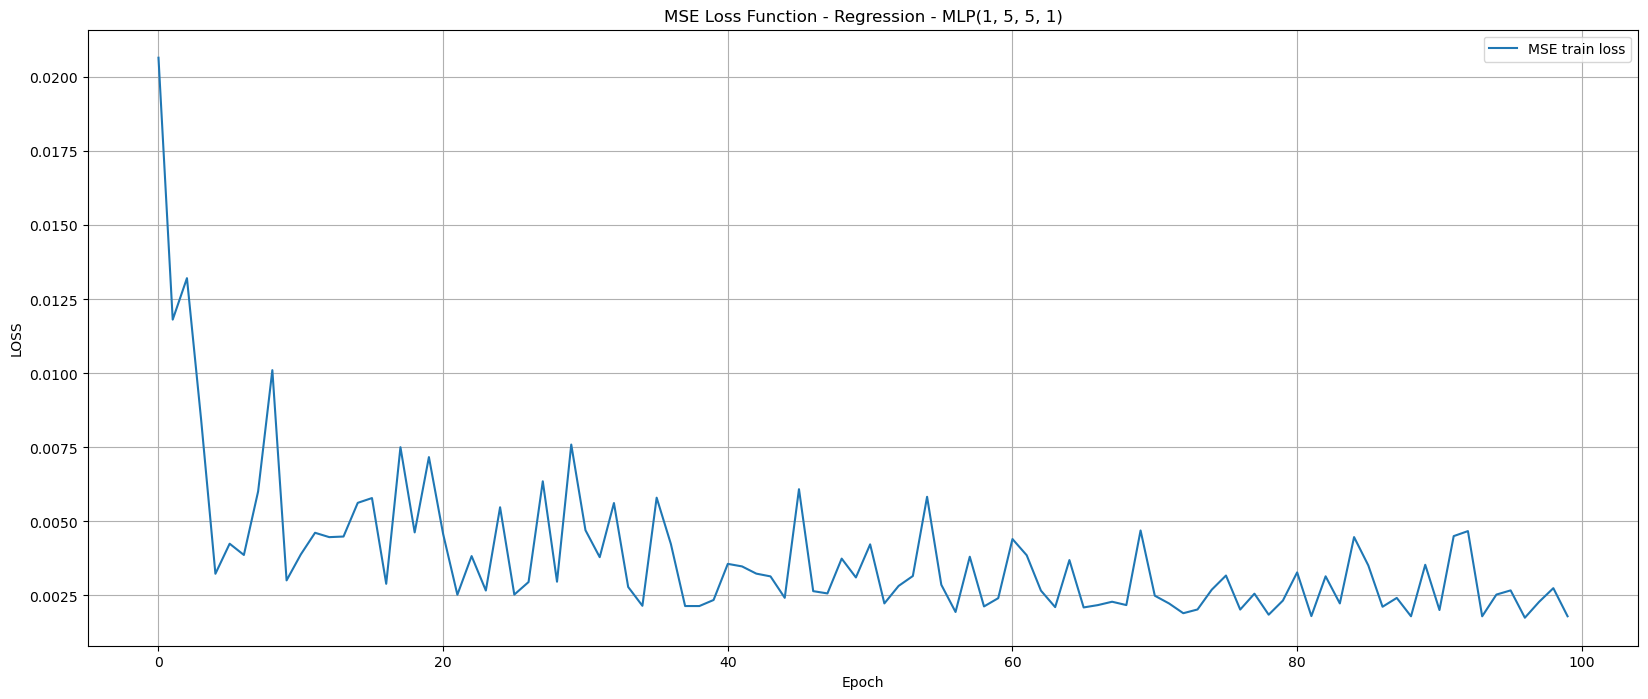

In [271]:
fig, ax = plt.subplots(figsize=(20,8))


ax.plot(trainingloss_gc, label='MSE train loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('LOSS')
ax.legend()
ax.grid()
ax.set_title("MSE Loss Function - Regression - MLP(1, 5, 5, 1)")

plt.show()

In [272]:
for p in model_gc.parameters():
    # print(p)
    p.requires_grad = False

In [534]:
entrada = torch.rand(5, requires_grad = True, device=device)
entrada

tensor([0.3468, 0.7627, 0.4551, 0.9521, 0.8137], device='cuda:0',
       requires_grad=True)

In [535]:
gc_target = torch.tensor(5.5 , dtype=torch.float32, device=device)
gc_target_scaled = gc_target/ torch.tensor(np.array(np.max(y_gc)), 
                                            dtype=torch.float32, device=device).reshape(1,)

In [536]:
gc_target_scaled

tensor([0.9197], device='cuda:0')

In [537]:
epsilon = torch.tensor(0.0001, dtype=torch.float32, device=device)
iterations = 10000

In [538]:
entrada_min = torch.zeros(5, dtype=torch.float32, device=device, requires_grad=False)
entrada_max = torch.ones(5, dtype=torch.float32, device=device, requires_grad=False)

In [554]:
for t in tqdm(range(iterations)):
    loss = criterion_gc(model_gc(entrada), gc_target_scaled)
    loss.backward()
    
    delta = epsilon*entrada.grad
    # break;
    with torch.no_grad():
        entrada_nueva = entrada - delta
        for i in range(5):
            if entrada_min[i] <= entrada_nueva[i]:
                 if entrada_nueva[i] <= entrada_max[i]:
                     entrada[i] = entrada_nueva[i]
        # print(entrada, "\n", entrada_nueva)
        y = model_gc(entrada)
        if torch.abs(y - gc_target_scaled) < epsilon:
            print(y,"\n", gc_target_scaled, "\n", entrada, )
            break;

  4%|█▎                                    | 351/10000 [00:00<00:10, 924.63it/s]

tensor([0.9196], device='cuda:0') 
 tensor([0.9197], device='cuda:0') 
 tensor([0.0724, 0.8811, 0.9811, 0.9776, 0.9435], device='cuda:0',
       requires_grad=True)


In [555]:
(entrada.cpu().detach().numpy() * (x_max - x_min)) + x_min

array([3.09974466e-01, 8.81099641e-01, 1.54125364e+01, 5.32277224e+03,
       2.97659576e+00])

In [546]:
materiales.columns

Index(['name', 'usablegc', 'usablevc', 'density', 'porosity', 'Ri', 'ssa',
       'specific'],
      dtype='object')